In [1]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_mistralai import MistralAIEmbeddings, ChatMistralAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

C:\Users\GEO COMPUTER S\AppData\Local\Temp\ipykernel_24004\2995084614.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
# 1) Load (single book, replacing tutor's book1/book2/book3 setup)
docs = PyPDFLoader("./documents/software_project_man_book.pdf").load()

fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/ZJXUGY+HelveticaLTStd-Bold', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(7982, 0, 2297343780448), '/LastChar': 121, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [278, 333, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 278, 333, 0, 0, 556, 556, 556, 556, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 611, 0, 722, 722, 722, 722, 667, 611, 778, 722, 278, 556, 722, 611, 833, 722, 778, 667, 0, 722, 667, 611, 722, 0, 944, 0, 667, 611, 0, 0, 0, 0, 0, 0, 556, 611, 556, 611, 556, 333, 611, 611, 278, 278, 556, 278, 889, 611, 611, 611, 0, 389, 556, 333, 611, 0, 778, 556, 556]}, but is not installed. Consider installing fontTools if you encounter encoding problems.


fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/ZJXUGY+HelveticaLTStd-Bold', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(7982, 0, 2297343780448), '/LastChar': 121, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [278, 333, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 278, 333, 0, 0, 556, 556, 556, 556, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 611, 0, 722, 722, 722, 722, 667, 611, 778, 722, 278, 556, 722, 611, 833, 722, 778, 667, 0, 722, 667, 611, 722, 0, 944, 0, 667, 611, 0, 0, 0, 0, 0, 0, 556, 611, 556, 611, 556, 333, 611, 611, 278, 278, 556, 278, 889, 611, 611, 611, 0, 389, 556, 333, 611, 0, 778, 556, 556]}, but is not installed. Consider installing fontTools if you encounter encoding problems.


fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/ZWZPOA+Caslon224Std-Bold', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(7988, 0, 2297343780448), '/LastChar': 213, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [296, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 296, 0, 296, 0, 593, 593, 593, 593, 593, 593, 593, 593, 593, 593, 296, 0, 0, 0, 0, 0, 0, 704, 667, 704, 759, 0, 611, 778, 0, 370, 0, 722, 0, 889, 0, 796, 630, 0, 0, 593, 630, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 500, 593, 481, 593, 500, 315, 0, 593, 296, 0, 574, 296, 0, 593, 574, 593, 0, 426, 426, 352, 593, 0, 741, 556, 500, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 241]}, but is not installed. Consider installing f

fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/ANNFQF+Caslon224Std-BookItalic', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(7985, 0, 2297343780448), '/LastChar': 213, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [278, 0, 0, 0, 556, 741, 759, 0, 407, 407, 0, 0, 278, 333, 278, 278, 556, 556, 556, 556, 556, 556, 556, 556, 556, 556, 278, 0, 0, 0, 0, 0, 800, 630, 611, 704, 704, 630, 593, 778, 722, 352, 481, 648, 593, 833, 704, 778, 593, 778, 630, 593, 630, 704, 611, 870, 630, 593, 630, 0, 0, 0, 0, 0, 0, 574, 556, 500, 593, 463, 296, 519, 574, 315, 296, 574, 296, 889, 611, 519, 593, 556, 444, 463, 333, 611, 574, 852, 574, 500, 500, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 800, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/DTJMFN+KievitOT-Book', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(4775, 0, 2297343780448), '/LastChar': 169, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [219, 0, 0, 0, 0, 0, 0, 0, 316, 317, 0, 0, 233, 0, 233, 411, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 237, 0, 0, 0, 0, 0, 0, 637, 0, 616, 684, 508, 0, 0, 0, 290, 292, 581, 481, 858, 0, 0, 552, 0, 580, 502, 505, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 478, 526, 444, 530, 496, 326, 511, 533, 256, 0, 478, 248, 799, 535, 532, 535, 0, 354, 410, 356, 534, 471, 707, 0, 478, 430, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 859]}, but is not installed. Consider installing fontTools if you encounter encoding problems.


...

fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/OGPFYJ+HelveticaLTStd-Bold', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(8450, 0, 2297343780448), '/LastChar': 122, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [278, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 278, 0, 556, 556, 556, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 722, 722, 722, 722, 667, 611, 778, 722, 278, 556, 722, 611, 833, 722, 778, 667, 778, 722, 667, 611, 722, 667, 944, 667, 667, 611, 0, 0, 0, 0, 0, 0, 556, 611, 556, 0, 556, 333, 611, 611, 278, 0, 556, 278, 889, 611, 611, 611, 0, 389, 556, 333, 611, 0, 0, 0, 556, 500]}, but is not installed. Consider installing fontTools if you encounter encoding problems.


fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/GTUDKL+HelveticaLTStd-Roman', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(8014, 0, 2297343780448), '/LastChar': 213, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [278, 0, 0, 0, 0, 889, 0, 0, 333, 333, 0, 584, 278, 333, 278, 278, 556, 556, 556, 556, 556, 556, 556, 556, 556, 556, 278, 0, 0, 0, 0, 556, 0, 667, 667, 722, 722, 667, 611, 778, 722, 278, 500, 667, 556, 833, 722, 778, 667, 778, 722, 667, 611, 722, 667, 944, 667, 667, 0, 0, 0, 0, 0, 556, 0, 556, 556, 500, 556, 556, 278, 556, 556, 222, 222, 500, 222, 833, 556, 556, 556, 556, 333, 500, 278, 556, 500, 722, 500, 500, 500, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 737, 737, 1000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 556

fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/GKUXMP+Caslon224Std-Book', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(8037, 0, 2297343780448), '/LastChar': 213, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [278, 389, 0, 556, 556, 648, 741, 222, 389, 389, 481, 600, 278, 333, 278, 278, 556, 556, 556, 556, 556, 556, 556, 556, 556, 556, 278, 278, 0, 600, 0, 556, 800, 667, 630, 704, 704, 630, 574, 759, 722, 352, 444, 648, 611, 796, 685, 778, 574, 778, 667, 574, 648, 685, 667, 907, 667, 611, 593, 389, 0, 389, 0, 0, 0, 500, 556, 500, 556, 500, 296, 463, 593, 296, 296, 556, 278, 870, 593, 537, 556, 556, 407, 426, 352, 574, 500, 722, 537, 537, 481, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 500, 0, 0, 0, 296, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 800, 800, 990, 0, 0, 0, 0, 0, 0, 600, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 537, 0, 0, 0, 0, 0, 0, 0, 0, 0

fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/ANNFQF+Caslon224Std-BookItalic', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(7985, 0, 2297343780448), '/LastChar': 213, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [278, 0, 0, 0, 556, 741, 759, 0, 407, 407, 0, 0, 278, 333, 278, 278, 556, 556, 556, 556, 556, 556, 556, 556, 556, 556, 278, 0, 0, 0, 0, 0, 800, 630, 611, 704, 704, 630, 593, 778, 722, 352, 481, 648, 593, 833, 704, 778, 593, 778, 630, 593, 630, 704, 611, 870, 630, 593, 630, 0, 0, 0, 0, 0, 0, 574, 556, 500, 593, 463, 296, 519, 574, 315, 296, 574, 296, 889, 611, 519, 593, 556, 444, 463, 333, 611, 574, 852, 574, 500, 500, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 800, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/BaseFont': '/ALLXZG+Caslon224Std-Bold', '/Encoding': '/MacRomanEncoding', '/FirstChar': 32, '/FontDescriptor': IndirectObject(8052, 0, 2297343780448), '/LastChar': 213, '/Subtype': '/Type1', '/Type': '/Font', '/Widths': [296, 0, 0, 0, 0, 833, 815, 0, 407, 407, 0, 600, 296, 333, 296, 278, 593, 593, 593, 593, 593, 593, 593, 593, 593, 593, 296, 0, 0, 0, 0, 0, 0, 704, 667, 704, 759, 667, 611, 778, 778, 370, 481, 722, 630, 889, 722, 796, 630, 796, 704, 593, 630, 704, 685, 963, 685, 630, 593, 0, 0, 0, 0, 0, 0, 500, 593, 481, 593, 500, 315, 519, 593, 296, 296, 574, 296, 852, 593, 574, 593, 593, 426, 426, 352, 593, 500, 741, 556, 500, 500, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 444, 44

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [4]:
embeddings = MistralAIEmbeddings(model="mistral-embed")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

D:\crag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
llm = ChatMistralAI(model="ministral-8b-latest", temperature=0)

In [6]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [7]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [8]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []

    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [9]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful project management tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided book.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

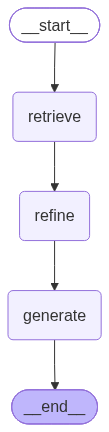

In [10]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [11]:
res = app.invoke({
    "question": "What is scope creep in project management?",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

- **Scope creep** refers to the **uncontrolled expansion** of a project’s scope beyond what was originally planned or approved.
- It occurs when **additional features, deliverables, or changes** are continuously added to the project without proper evaluation or approval.
- Scope creep often leads to:
  - **Increased costs** (due to extra work, resources, or time).
  - **Delayed timelines** (as the project becomes more complex).
  - **Reduced quality** (if resources are stretched thin).
  - **Stakeholder dissatisfaction** (if expectations aren’t managed).
- **Common causes** include:
  - Poorly defined or **unclear initial scope**.
  - Lack of **formal change control processes**.
  - **Unmanaged stakeholder requests** (e.g., "just one more feature").
  - **Lack of scope validation** with users or sponsors.
- **Mitigation strategies** include:
  - **Thoroughly documenting and validating** the initial scope.
  - Implementing a **formal change control process** for scope adjustments.
  - *

In [12]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

velop a process for controlling scope changes.
Scope creep can also be a good thing, if managed well. Later in this chapter, you can 
see how Northwest Airlines encouraged scope changes on its ResNet project and managed 
them well.
WHAT WENT WR O NG?
A project scope that is too broad and grandiose can cause severe problems. Scope creep 
and an overemphasis on technology for technology’s sake resulted in the bankruptcy of a 
large pharmaceutical firm, Texas-based FoxMeyer Drug. In 1994, the CIO was pushing for 
a $65 million system to manage the company’s critical operations. He did not believe in 
keeping things simple, however. The company spent nearly $10 million on state-of-the-
art hardware and software and contracted the management of the project to a prestigious 
(and expensive) consulting firm. The project included building an $18 million robotic
****************************************************************************************************
ables. In this case, the project 

In [13]:
print(res['refined_context'])

A project scope that is too broad and grandiose can cause severe problems.
Even when the project scope is fairly well defined, many IT projects suffer from scope creep—the tendency for project scope to keep getting bigger and bigger.
For this reason, it is very important to verify the project scope with users throughout the life of the project and de- velop a process for controlling scope changes.
You cannot do a good job of controlling scope if you do not first do a good job of collecting requirements, defining scope, and validating scope.
A critically important and difficult aspect of project management is defining the scope of a project.
